<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-22-power-transformer-in-scikit-learn?scriptVersionId=340797384" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🤖 ML 22 — Power Transformer in Scikit-learn

### **Normalize Skewed Features using Yeo-Johnson & Box-Cox Transformations**
---

# 🚀 Introduction

Power Transformation is a feature engineering technique used to reduce skewness and make numerical features follow a more Gaussian (normal) distribution.

Many Machine Learning algorithms, especially Linear Regression, assume that the data is approximately normally distributed. Highly skewed features can reduce model performance.

In this notebook, we'll learn how to:

* Understand skewed distributions
* Visualize feature distributions
* Apply PowerTransformer
* Compare Yeo-Johnson and Box-Cox
* Evaluate model performance before and after transformation

---
# 📦 Import Libraries

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer

---
# 📂 Load Dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/ahmedfakhar123/concrete-strength-prediction-dataset/concrete_data.csv")
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [4]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


---
# 🎯 Prepare Features

In [5]:
X = df.drop(columns=["Strength"])
y = df["Strength"]

---
# ✂️ Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

---
# 🤖 Baseline Linear Regression

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))

R² Score: 0.6234704748356754


In [8]:
# Cross checking with cross val score
lr = LinearRegression()
np.mean(cross_val_score(lr, X, y, scoring='r2'))

np.float64(0.46099404916628606)

---
# 📈 Distribution Before Transformation

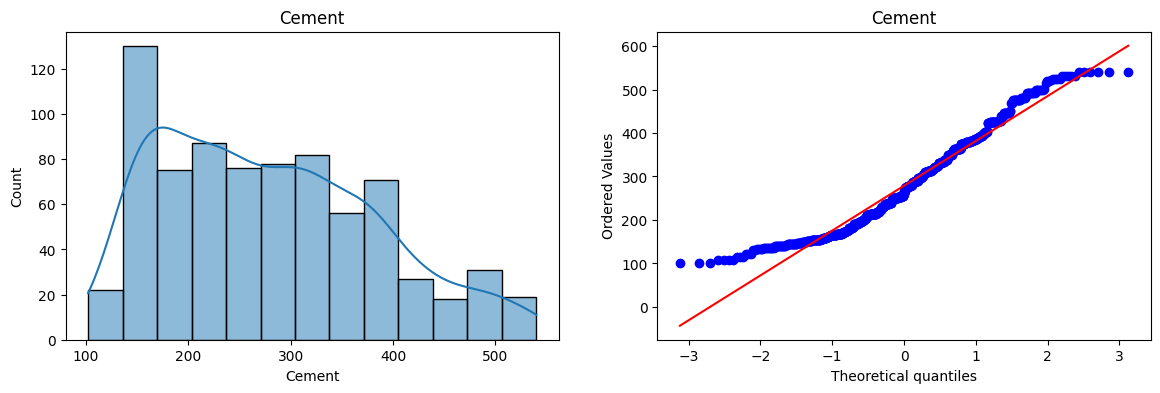

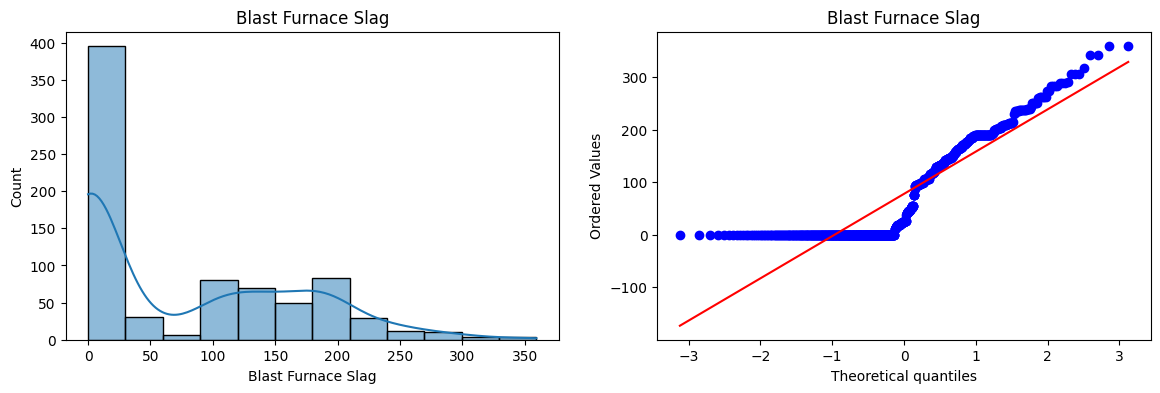

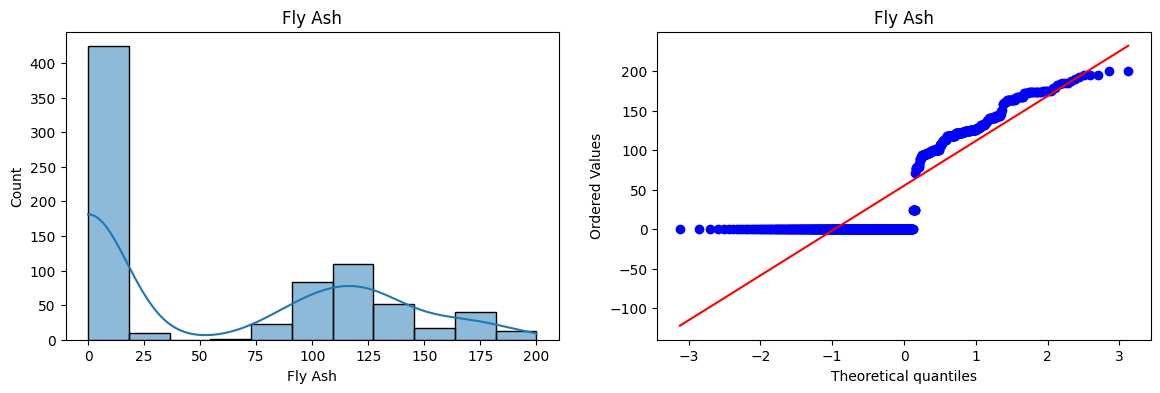

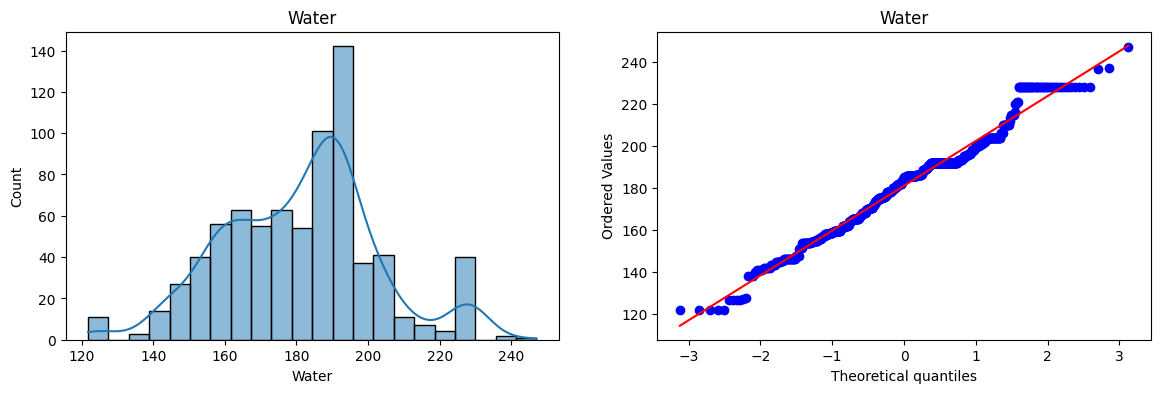

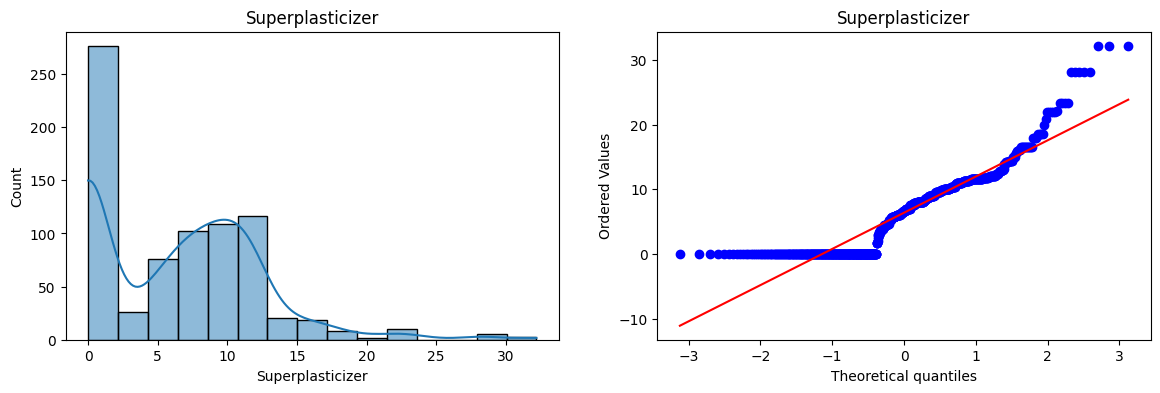

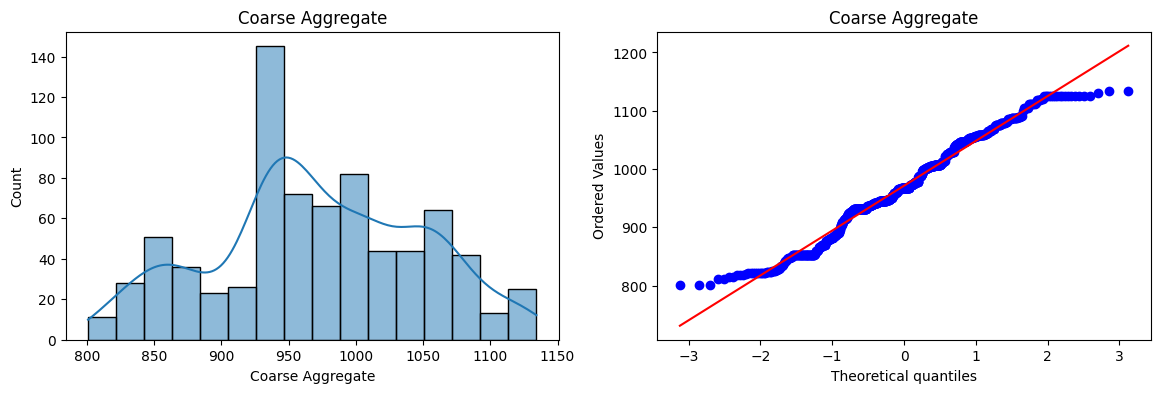

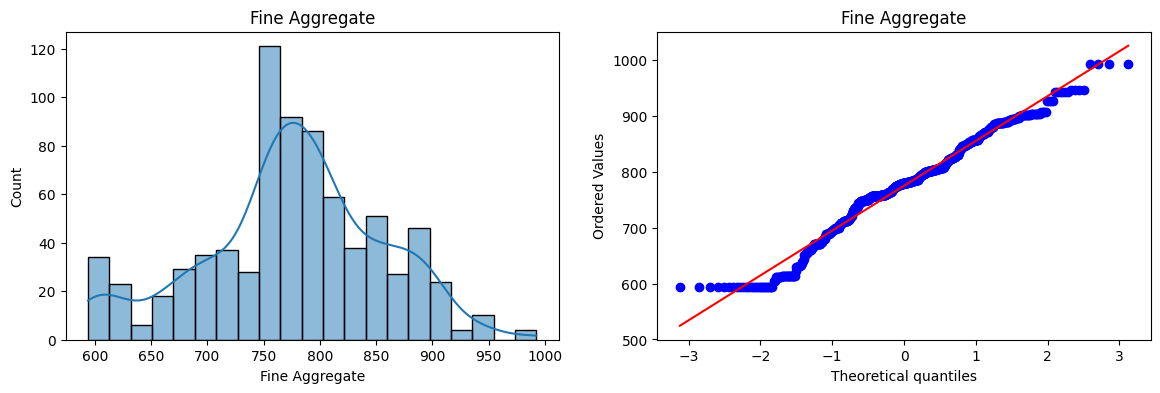

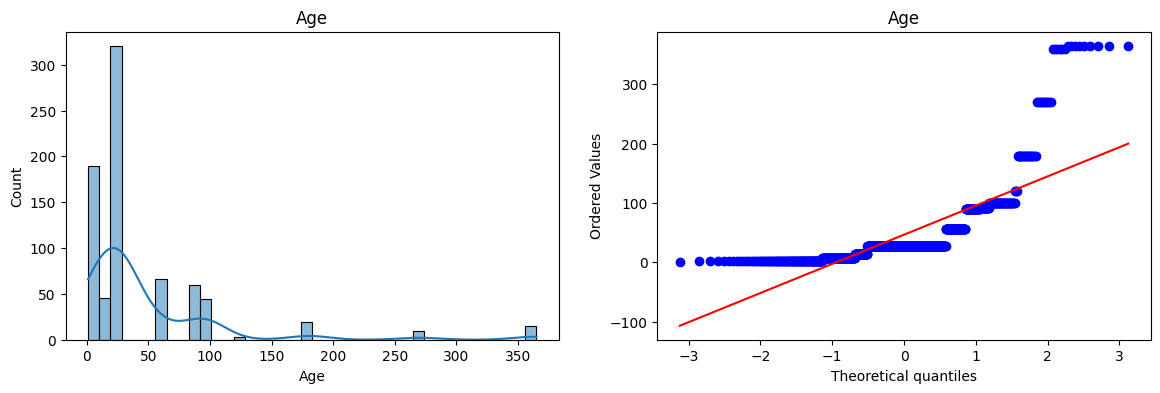

In [9]:
# Plotting the distplots without any transformation

for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

---
# ⚡ Applying Power Transformer

We'll transform only the numerical features:

* Model Year
* Mileage
* Engine Capacity

using the Yeo-Johnson method

In [10]:
transformer = PowerTransformer()

X_train_tr = transformer.fit_transform(X_train)
X_test_tr = transformer.transform(X_test)

pd.DataFrame({'cols': X_train.columns, 'box_cox_lambdas': transformer.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.149907
1,Blast Furnace Slag,0.038050
2,Fly Ash,-0.134305
3,Water,0.860033
4,Superplasticizer,0.306351
5,Coarse Aggregate,1.193036
6,Fine Aggregate,1.823333
7,Age,0.009636


---
# 🏋️ Train Model After Transformation

In [11]:
model = LinearRegression()

model.fit(X_train_tr, y_train)

y_pred_tr = model.predict(X_test_tr)

print("R² Score:", r2_score(y_test, y_pred_tr))

R² Score: 0.8247390754875865


---
# 📊 Before vs After Distribution

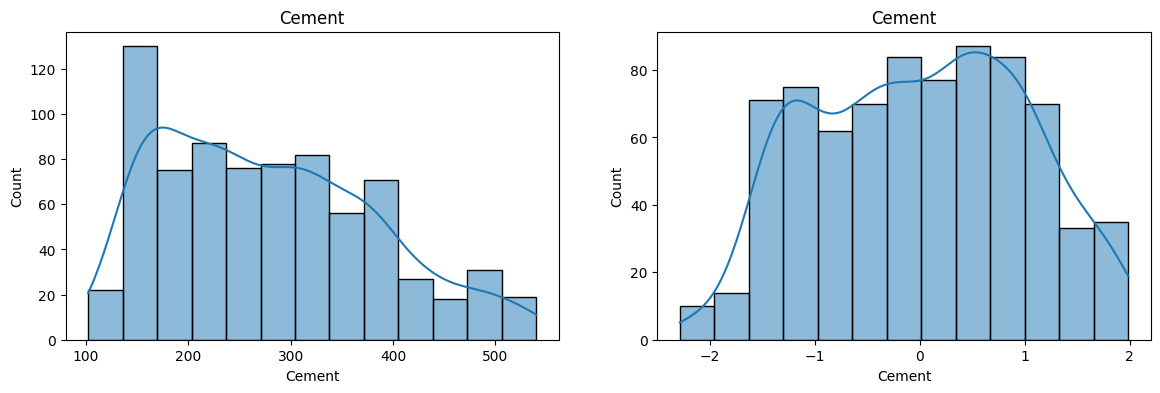

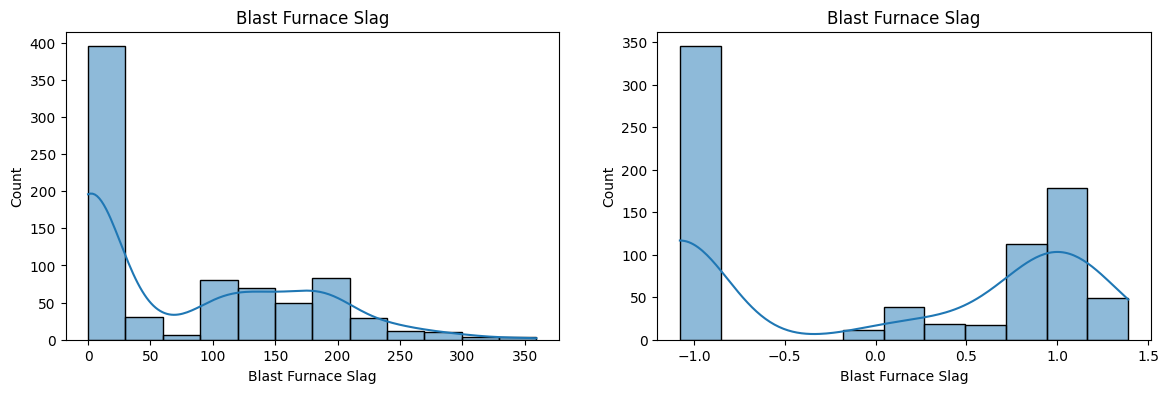

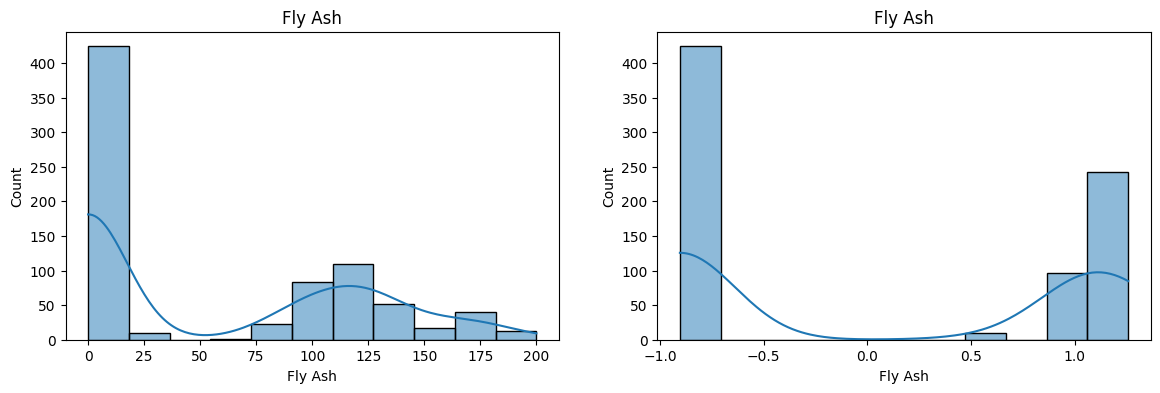

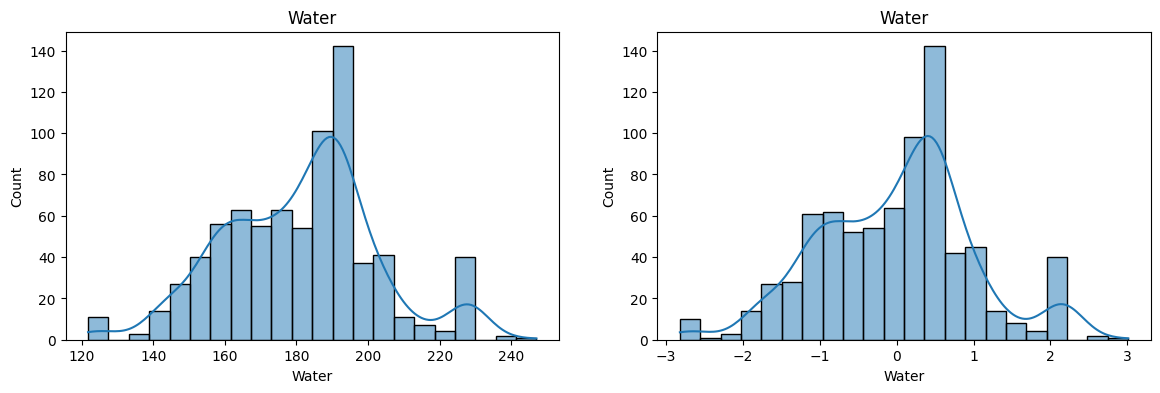

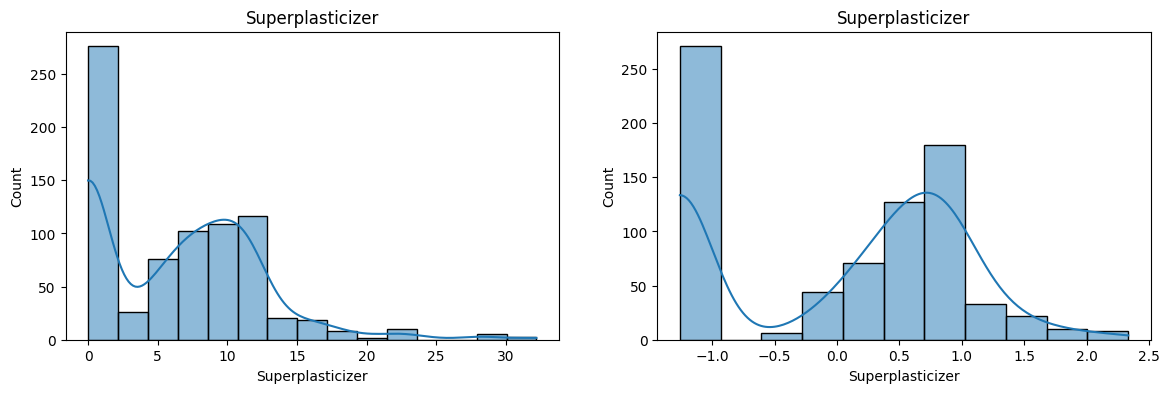

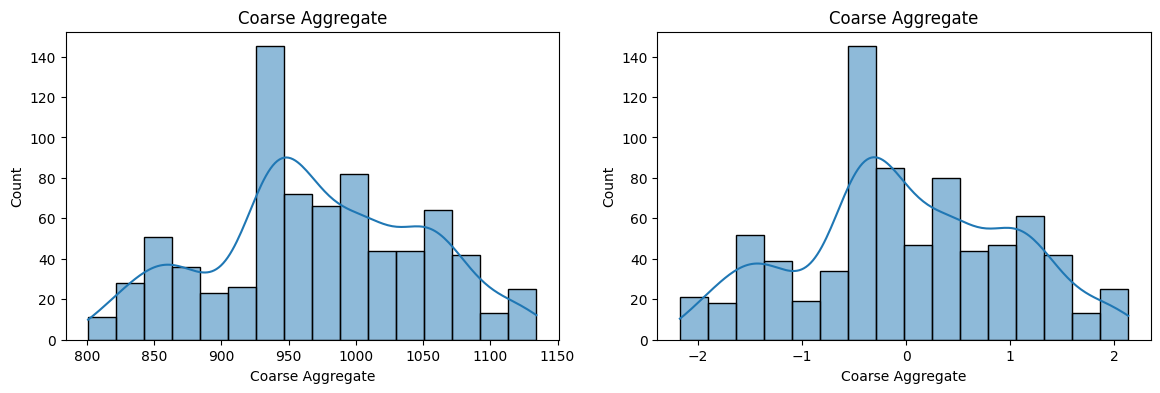

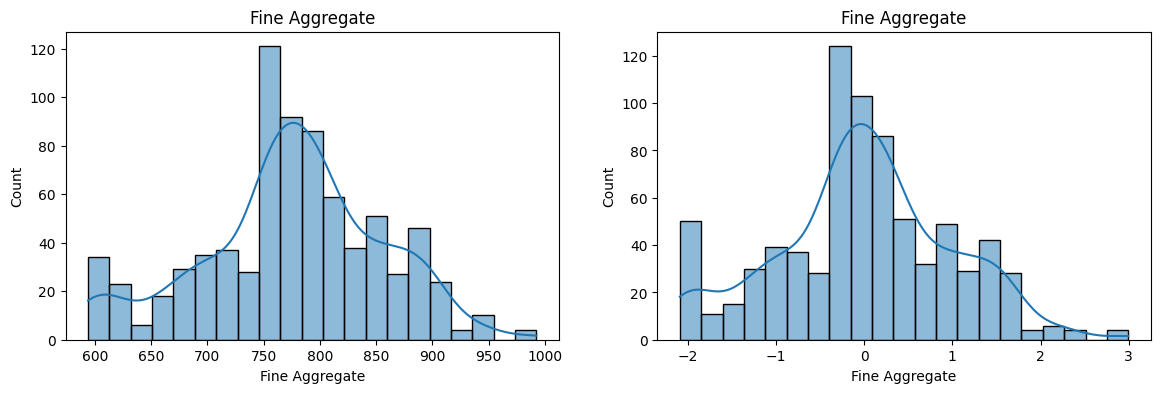

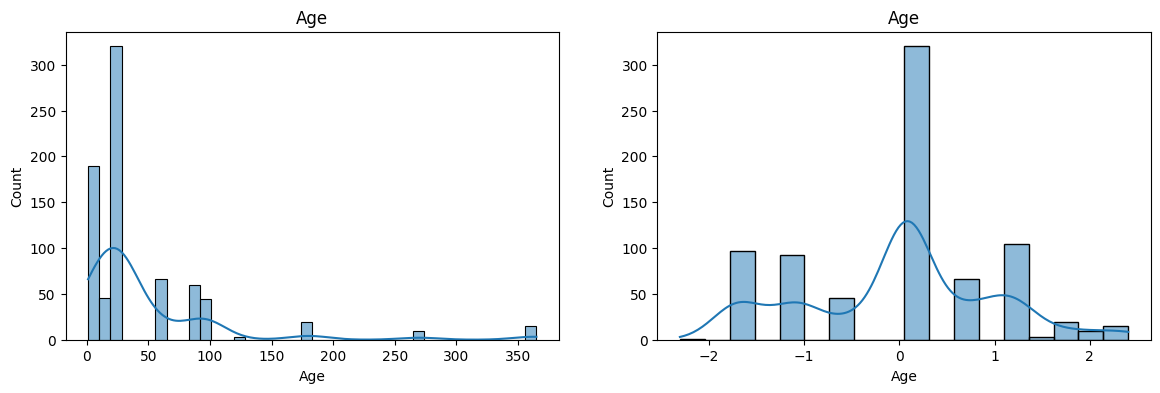

In [12]:
# Plotting the distplots with any transformation
X_train_tr = pd.DataFrame(X_train_tr, columns=X_train.columns)

for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(X_train_tr[col], kde=True)
    plt.title(col)

    plt.show()

---

# 🧠 Yeo-Johnson vs Box-Cox

| Yeo-Johnson                | Box-Cox                           |
| -------------------------- | --------------------------------- |
| Works with zero values     | ❌ No                              |
| Works with negative values | ❌ No                              |
| Most commonly used         | Only positive data                |
| Default in sklearn         | Requires strictly positive values |

---

# 💡 When Should You Use Power Transformation?

Use it when:

* 📈 Numerical features are highly skewed.
* 🤖 You're using Linear Regression, Logistic Regression, or Neural Networks.
* 📊 Features don't follow a Gaussian distribution.
* 🎯 You want better model performance.

Avoid it when:

* 🌳 Using tree-based models like Random Forest, XGBoost, or Decision Trees, since they generally don't benefit from feature transformations.


---

# 🎉 Conclusion

In this notebook, we learned how Power Transformation helps convert skewed numerical features into distributions closer to normal. We applied the **Yeo-Johnson** method using `PowerTransformer`, visualized the effect with histograms and QQ plots, and evaluated a Linear Regression model before and after transformation.

Although the performance improvement depends on the dataset, Power Transformation is a valuable preprocessing technique for many algorithms that assume normally distributed features.

---

## ⏭️ What's Next?

[**🤖 ML 23 — Binning & Discretization in Scikit-learn**](http://)

In the next notebook, we'll explore **Binning & Discretization**, a powerful feature engineering technique that converts continuous numerical values into discrete intervals (bins). You'll learn how to simplify complex data, reduce the impact of outliers, and create more meaningful features using multiple binning strategies in Scikit-learn.

We'll cover:

* 📦 Uniform (Equal Width) Binning
* 📊 Quantile (Equal Frequency) Binning
* 🎯 KMeans Binning
* ⚙️ Using `KBinsDiscretizer`
* 🤖 When binning improves Machine Learning models